In [7]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, f1_score, balanced_accuracy_score
from skopt import BayesSearchCV
from skopt.space import Real, Integer
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import time
from datetime import datetime

# ========================================
# PARTIE 1: BALANCED RANDOM FOREST FROM SCRATCH 
# ========================================

class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature      
        self.threshold = threshold  
        self.left = left           
        self.right = right         
        self.value = value         

class DecisionTree:
    def __init__(self, max_depth=10, min_samples_split=2, min_samples_leaf=1, max_features=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.root = None
    
    def fit(self, X, y):
        self.n_features = X.shape[1]
        if self.max_features is None:
            self.max_features = int(np.sqrt(self.n_features))
        self.root = self._grow_tree(X, y)
    
    def _gini_impurity(self, y):
        proportions = np.bincount(y) / len(y)
        return 1 - np.sum(proportions ** 2)
    
    def _split(self, X, y, feature, threshold):
        left_mask = X[:, feature] <= threshold
        right_mask = ~left_mask
        return X[left_mask], X[right_mask], y[left_mask], y[right_mask]
    
    def _best_split(self, X, y):
        best_gain = -1
        best_feature = None
        best_threshold = None
        
        features = np.random.choice(self.n_features, self.max_features, replace=False)
        
        for feature in features:
            unique_vals = np.unique(X[:, feature])
            if len(unique_vals) > 10:
                indices = np.linspace(0, len(unique_vals)-1, 10, dtype=int)
                thresholds = unique_vals[indices]
            else:
                thresholds = unique_vals
            
            for threshold in thresholds:
                X_left, X_right, y_left, y_right = self._split(X, y, feature, threshold)
                
                if len(y_left) < self.min_samples_leaf or len(y_right) < self.min_samples_leaf:
                    continue
                
                gini_parent = self._gini_impurity(y)
                n = len(y)
                n_left, n_right = len(y_left), len(y_right)
                gini_left = self._gini_impurity(y_left)
                gini_right = self._gini_impurity(y_right)
                
                gain = gini_parent - (n_left/n * gini_left + n_right/n * gini_right)
                
                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature
                    best_threshold = threshold
        
        return best_feature, best_threshold
    
    def _grow_tree(self, X, y, depth=0):
        n_samples, n_features = X.shape
        n_labels = len(np.unique(y))
        
        if (depth >= self.max_depth or 
            n_labels == 1 or 
            n_samples < self.min_samples_split):
            leaf_value = Counter(y).most_common(1)[0][0]
            return Node(value=leaf_value)
        
        best_feature, best_threshold = self._best_split(X, y)
        
        if best_feature is None:
            leaf_value = Counter(y).most_common(1)[0][0]
            return Node(value=leaf_value)
        
        X_left, X_right, y_left, y_right = self._split(X, y, best_feature, best_threshold)
        left = self._grow_tree(X_left, y_left, depth + 1)
        right = self._grow_tree(X_right, y_right, depth + 1)
        
        return Node(feature=best_feature, threshold=best_threshold, left=left, right=right)
    
    def _traverse_tree(self, x, node):
        if node.value is not None:
            return node.value
        
        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)
    
    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])


class BalancedRandomForest:
    """
    Balanced Random Forest qui gère le déséquilibre des classes.
    
    Stratégies implémentées:
    1. Bootstrap équilibré: sous-échantillonne la classe majoritaire
    2. Pondération des votes: ajuste l'importance selon la fréquence des classes
    """
    
    def __init__(self, n_estimators=100, max_depth=10, min_samples_split=2, 
                 min_samples_leaf=1, max_features=None, sampling_strategy='auto',
                 replacement=False):
        """
        Parameters:
        -----------
        sampling_strategy : str or dict
            - 'auto': équilibre toutes les classes à la taille de la classe majoritaire
            - 'all': équilibre toutes les classes
            - dict: {class_label: n_samples} pour contrôle manuel
        replacement : bool
            Si True, sous-échantillonnage avec remise
        """
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.sampling_strategy = sampling_strategy
        self.replacement = replacement
        self.trees = []
        self.class_weights = None
    
    def _calculate_class_weights(self, y):
        """Calcule les poids des classes pour pondérer les votes"""
        class_counts = Counter(y)
        total = len(y)
        weights = {}
        for cls, count in class_counts.items():
            weights[cls] = total / (len(class_counts) * count)
        return weights
    
    def _balanced_bootstrap_sample(self, X, y):
        """
        Crée un échantillon bootstrap équilibré.
        Sous-échantillonne la classe majoritaire pour équilibrer.
        """
        unique_classes = np.unique(y)
        class_counts = Counter(y)
        
        if self.sampling_strategy == 'auto':
            # Prendre le minimum entre toutes les classes
            n_samples_per_class = min(class_counts.values())
        elif self.sampling_strategy == 'all':
            # Équilibrer toutes les classes à la taille de la classe majoritaire
            n_samples_per_class = max(class_counts.values())
        else:
            n_samples_per_class = min(class_counts.values())
        
        balanced_indices = []
        
        for cls in unique_classes:
            cls_indices = np.where(y == cls)[0]
            
            # Sous-échantillonnage ou sur-échantillonnage selon la taille
            if len(cls_indices) >= n_samples_per_class:
                # Sous-échantillonnage
                sampled_indices = np.random.choice(
                    cls_indices, 
                    size=n_samples_per_class, 
                    replace=self.replacement
                )
            else:
                # Sur-échantillonnage (avec remise)
                sampled_indices = np.random.choice(
                    cls_indices, 
                    size=n_samples_per_class, 
                    replace=True
                )
            
            balanced_indices.extend(sampled_indices)
        
        balanced_indices = np.array(balanced_indices)
        np.random.shuffle(balanced_indices)
        
        return X[balanced_indices], y[balanced_indices]
    
    def fit(self, X, y):
        """Entraîne la forêt équilibrée"""
        self.trees = []
        self.class_weights = self._calculate_class_weights(y)
        
        print(f"\n🎯 Balanced Random Forest:")
        print(f"   Distribution originale: {Counter(y)}")
        print(f"   Poids des classes: {self.class_weights}")
        
        for i in range(self.n_estimators):
            tree = DecisionTree(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                min_samples_leaf=self.min_samples_leaf,
                max_features=self.max_features
            )
            
            # Échantillonnage équilibré
            X_sample, y_sample = self._balanced_bootstrap_sample(X, y)
            
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)
            
            if (i + 1) % 20 == 0:
                print(f"   ✅ {i + 1}/{self.n_estimators} arbres entraînés")
    
    def predict(self, X):
        """Prédictions avec vote pondéré par les poids des classes"""
        tree_predictions = np.array([tree.predict(X) for tree in self.trees])
        n_samples = X.shape[0]
        
        predictions = []
        for i in range(n_samples):
            votes = tree_predictions[:, i]
            
            # Vote pondéré
            weighted_votes = {}
            for vote in votes:
                weight = self.class_weights.get(vote, 1.0)
                weighted_votes[vote] = weighted_votes.get(vote, 0) + weight
            
            # Classe avec le vote pondéré maximum
            predicted_class = max(weighted_votes.items(), key=lambda x: x[1])[0]
            predictions.append(predicted_class)
        
        return np.array(predictions)
    
    def predict_proba(self, X):
        """Probabilités prédites avec pondération"""
        tree_predictions = np.array([tree.predict(X) for tree in self.trees])
        n_samples = X.shape[0]
        unique_classes = np.unique(tree_predictions)
        n_classes = len(unique_classes)
        
        probas = np.zeros((n_samples, n_classes))
        
        for i in range(n_samples):
            votes = tree_predictions[:, i]
            
            # Comptage pondéré des votes
            weighted_counts = np.zeros(n_classes)
            for vote in votes:
                cls_idx = np.where(unique_classes == vote)[0][0]
                weight = self.class_weights.get(vote, 1.0)
                weighted_counts[cls_idx] += weight
            
            # Normalisation pour obtenir des probabilités
            probas[i] = weighted_counts / np.sum(weighted_counts)
        
        return probas


# ========================================
# PARTIE 2: CHARGEMENT ET PRÉPARATION
# ========================================

start_time = time.time()

print("=" * 60)
print("BALANCED RANDOM FOREST - GESTION DU DÉSÉQUILIBRE")
print("=" * 60)

# Charger les données
df = pd.read_csv(r"C:\Users\MECHERI INFORMATIQUE\Desktop\DM\merged_feature_final.csv")
print(f"\n📊 Dataset chargé: {df.shape[0]} lignes, {df.shape[1]} colonnes")

# Afficher les premières lignes
print("\n🔍 Aperçu des données:")
print(df.head())

# Vérifier les valeurs manquantes
missing = df.isnull().sum()
if missing.sum() > 0:
    print("\n❌ Valeurs manquantes détectées - Suppression des lignes:")
    print(missing[missing > 0])
    df = df.dropna()
    print(f"✅ Dataset après nettoyage: {df.shape[0]} lignes")

# Séparer features et target
TARGET_COLUMN = 'class'

if TARGET_COLUMN in df.columns:
    print(f"\n✅ Colonne target '{TARGET_COLUMN}' trouvée!")
    y = df[TARGET_COLUMN]
    X = df.drop(TARGET_COLUMN, axis=1)
elif 'target' in df.columns:
    print(f"\n✅ Colonne 'target' trouvée!")
    y = df['target']
    X = df.drop('target', axis=1)
else:
    print(f"\n⚠️ Colonne '{TARGET_COLUMN}' non trouvée, utilisation de la dernière colonne")
    X = df.iloc[:, :-1]
    y = df.iloc[:, -1]

print(f"\n✅ Features: {X.shape[1]} colonnes")
class_distribution = Counter(y)
print(f"✅ Distribution des classes: {class_distribution}")

# Calculer le ratio de déséquilibre
class_counts = list(class_distribution.values())
imbalance_ratio = max(class_counts) / min(class_counts)
print(f"⚠️ Ratio de déséquilibre: {imbalance_ratio:.2f}:1")

# Normalisation
print("\n🔄 Normalisation...")
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
print("✅ Normalisation terminée")

# ========================================
# PARTIE 3: SPLIT DES DONNÉES
# ========================================

print("\n" + "=" * 60)
print("PRÉPARATION DES DONNÉES")
print("=" * 60)

# Split avec stratify
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled.values, y.values, 
    test_size=0.2, random_state=42, stratify=y
)

print(f"\n📦 Train: {X_train.shape[0]} échantillons")
print(f"   Distribution: {Counter(y_train)}")
print(f"📦 Test: {X_test.shape[0]} échantillons")
print(f"   Distribution: {Counter(y_test)}")

# ========================================
# PARTIE 4: HYPERPARAMÈTRES PRÉDÉFINIS
# ========================================

print("\n" + "=" * 60)
print("HYPERPARAMÈTRES PRÉDÉFINIS (BALANCED RF)")
print("=" * 60)

# Hyperparamètres prédéfinis
best_params = {
    'n_estimators': 57,
    'max_depth': 14,
    'min_samples_split': 9,
    'min_samples_leaf': 3,
    'max_features': 6,
    'sampling_strategy': 'auto'
}

print("\n🎯 Hyperparamètres utilisés:")
for param, value in best_params.items():
    print(f"   {param}: {value}")

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# ========================================
# PARTIE 5: ENTRAÎNEMENT FINAL ET ÉVALUATION
# ========================================

print("\n" + "=" * 60)
print("ENTRAÎNEMENT DU MODÈLE FINAL (BALANCED RF)")
print("=" * 60)

train_start = time.time()
best_rf = BalancedRandomForest(**best_params)
best_rf.fit(X_train, y_train)
train_time = time.time() - train_start
print(f"✅ Entraînement terminé en {train_time:.2f} secondes")

# Prédictions
y_pred_train = best_rf.predict(X_train)
y_pred_test = best_rf.predict(X_test)

# Métriques standards
train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)
train_precision = precision_score(y_train, y_pred_train, average='weighted')
test_precision = precision_score(y_test, y_pred_test, average='weighted')
train_f1 = f1_score(y_train, y_pred_train, average='weighted')
test_f1 = f1_score(y_test, y_pred_test, average='weighted')

# Métriques équilibrées (importantes pour classes déséquilibrées)
train_balanced_acc = balanced_accuracy_score(y_train, y_pred_train)
test_balanced_acc = balanced_accuracy_score(y_test, y_pred_test)

print(f"\n📈 MÉTRIQUES STANDARDS:")
print(f"{'Métrique':<20} {'Train':<10} {'Test':<10} {'Gap':<10}")
print("-" * 55)
print(f"{'Accuracy':<20} {train_acc:<10.4f} {test_acc:<10.4f} {train_acc-test_acc:<10.4f}")
print(f"{'Balanced Accuracy':<20} {train_balanced_acc:<10.4f} {test_balanced_acc:<10.4f} {train_balanced_acc-test_balanced_acc:<10.4f}")
print(f"{'Precision':<20} {train_precision:<10.4f} {test_precision:<10.4f} {train_precision-test_precision:<10.4f}")
print(f"{'F1-Score':<20} {train_f1:<10.4f} {test_f1:<10.4f} {train_f1-test_f1:<10.4f}")

# Sauvegarder les métriques
metrics_data = {
    'Metric': ['Accuracy', 'Balanced Accuracy', 'Precision', 'F1-Score'],
    'Train': [train_acc, train_balanced_acc, train_precision, train_f1],
    'Test': [test_acc, test_balanced_acc, test_precision, test_f1],
    'Gap': [train_acc-test_acc, train_balanced_acc-test_balanced_acc, 
            train_precision-test_precision, train_f1-test_f1]
}
metrics_df = pd.DataFrame(metrics_data)
metrics_df.to_csv(f'balanced_rf_metrics_{timestamp}.csv', index=False)
print(f"\n💾 Métriques sauvegardées: balanced_rf_metrics_{timestamp}.csv")

# Classification Report
print("\n📊 Classification Report (Test):")
print(classification_report(y_test, y_pred_test))

report_dict = classification_report(y_test, y_pred_test, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv(f'balanced_rf_classification_report_{timestamp}.csv')
print(f"💾 Rapport sauvegardé: balanced_rf_classification_report_{timestamp}.csv")

# ========================================
# PARTIE 6: VISUALISATIONS
# ========================================

print("\n" + "=" * 60)
print("GÉNÉRATION DES VISUALISATIONS")
print("=" * 60)

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Nombre de prédictions'})
plt.title('Matrice de Confusion - Balanced Random Forest', fontsize=14, fontweight='bold')
plt.ylabel('Vraie classe', fontsize=12)
plt.xlabel('Classe prédite', fontsize=12)
plt.tight_layout()
plt.savefig(f'balanced_rf_confusion_matrix_{timestamp}.png', dpi=300, bbox_inches='tight')
print("✅ Matrice de confusion sauvegardée")
plt.close()

# Comparaison des métriques
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

metrics_names = ['Accuracy', 'Balanced\nAccuracy', 'Precision', 'F1-Score']
train_scores = [train_acc, train_balanced_acc, train_precision, train_f1]
test_scores = [test_acc, test_balanced_acc, test_precision, test_f1]

x = np.arange(len(metrics_names))
width = 0.35

bars1 = axes[0].bar(x - width/2, train_scores, width, label='Train', 
                    color='#3498db', edgecolor='black', linewidth=1.5)
bars2 = axes[0].bar(x + width/2, test_scores, width, label='Test', 
                    color='#e74c3c', edgecolor='black', linewidth=1.5)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', 
                    fontsize=10, fontweight='bold')

axes[0].set_xlabel('Métriques', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[0].set_title('Comparaison Train vs Test - Balanced RF', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_names)
axes[0].legend(fontsize=11)
axes[0].set_ylim([0, 1.1])
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# Performance par classe
report_dict = classification_report(y_test, y_pred_test, output_dict=True)
classes = [k for k in report_dict.keys() if k not in ['accuracy', 'macro avg', 'weighted avg']]
f1_scores = [report_dict[cls]['f1-score'] for cls in classes]
support = [report_dict[cls]['support'] for cls in classes]

colors = plt.cm.viridis(np.linspace(0, 1, len(classes)))
bars = axes[1].bar(classes, f1_scores, color=colors, edgecolor='black', linewidth=1.5)

for bar, sup in zip(bars, support):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}\n(n={sup})', ha='center', va='bottom', 
                fontsize=9, fontweight='bold')

axes[1].set_xlabel('Classe', fontsize=12, fontweight='bold')
axes[1].set_ylabel('F1-Score', fontsize=12, fontweight='bold')
axes[1].set_title('Performance par Classe (Test) - Balanced RF', fontsize=13, fontweight='bold')
axes[1].set_ylim([0, 1.1])
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(f'balanced_rf_metrics_comparison_{timestamp}.png', dpi=300, bbox_inches='tight')
print("✅ Graphiques de comparaison sauvegardés")
plt.close()

# Temps total
total_time = time.time() - start_time
print(f"\n⏱️ Temps total d'exécution: {total_time/60:.2f} minutes")
print("\n" + "=" * 60)
print("✅ ANALYSE TERMINÉE - TOUS LES FICHIERS SAUVEGARDÉS")
print("=" * 60)

BALANCED RANDOM FOREST - GESTION DU DÉSÉQUILIBRE

📊 Dataset chargé: 140165 lignes, 16 colonnes

🔍 Aperçu des données:
   latitude  longitude   TEB_log  CEC_CLAY  GYPSUM_log  TEXTURE_SOTER_encoded  \
0  36.74886    6.25409  2.995732      53.0    1.960095                    3.0   
1  35.87978    4.44782  3.806662      48.0    2.208274                    3.0   
2  35.70751    5.53337  3.806662      48.0    2.208274                    3.0   
3  32.27667    3.98647  3.806662      71.0    2.028148                    3.0   
4  32.40079    4.00642  3.806662      71.0    2.028148                    3.0   

   ORG_CARBON_log  LCCCODE_encoded  ELEC_COND_log  COARSE  \
0        2.205193              1.0       1.945910    11.0   
1        2.099734              3.0       2.079442     5.0   
2        2.099734             16.0       2.079442     5.0   
3        2.040571             18.0       2.197225     3.0   
4        2.040571              3.0       2.197225     3.0   

   TEXTURE_USDA_encoded  cla

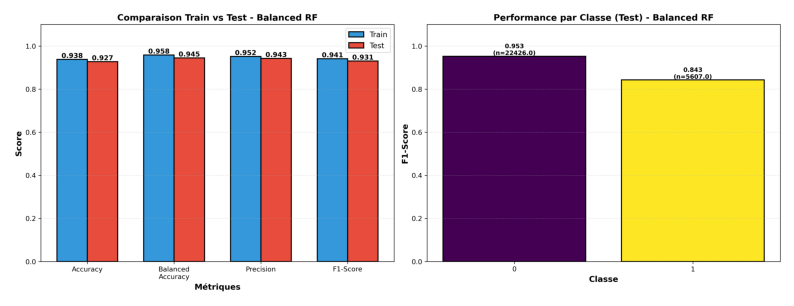

In [11]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Chemin vers ton fichier
img_path = r"C:\Users\MECHERI INFORMATIQUE\Desktop\DM\balanced_rf_metrics_comparison_20251201_221015.png"

# Charger et afficher
img = mpimg.imread(img_path)
plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis('off')  # enlever les axes
plt.show()


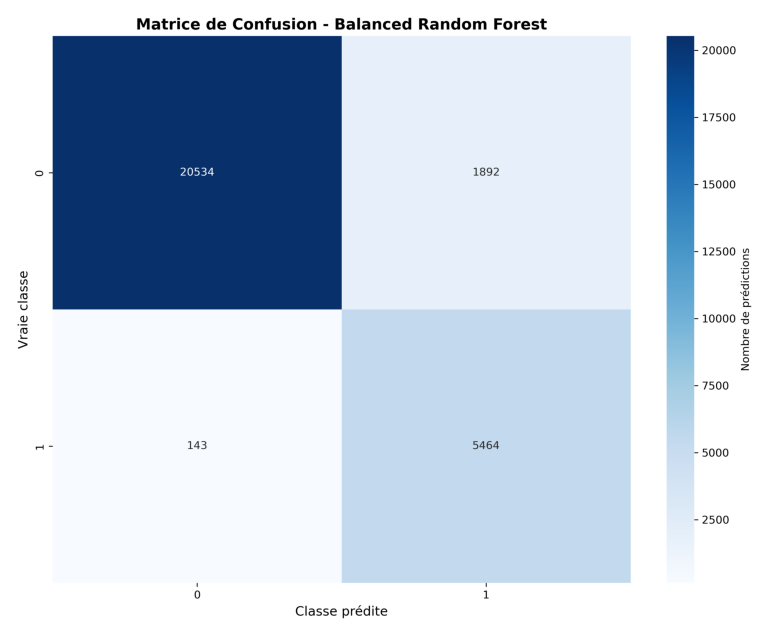

In [12]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Chemin vers ton fichier
img_path = r"C:\Users\MECHERI INFORMATIQUE\Desktop\DM\balanced_rf_confusion_matrix_20251201_221015.png"

# Charger et afficher
img = mpimg.imread(img_path)
plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis('off')  # enlever les axes
plt.show()


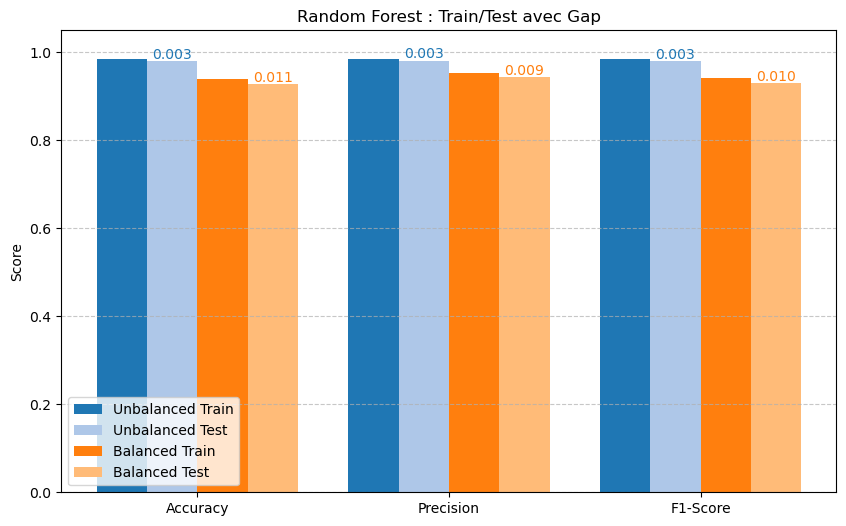

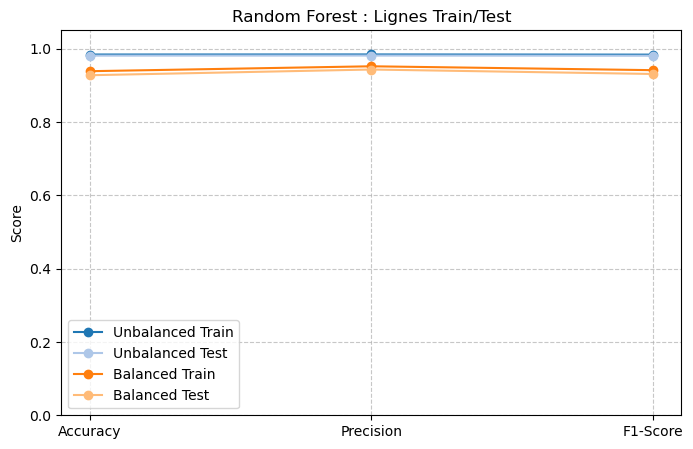

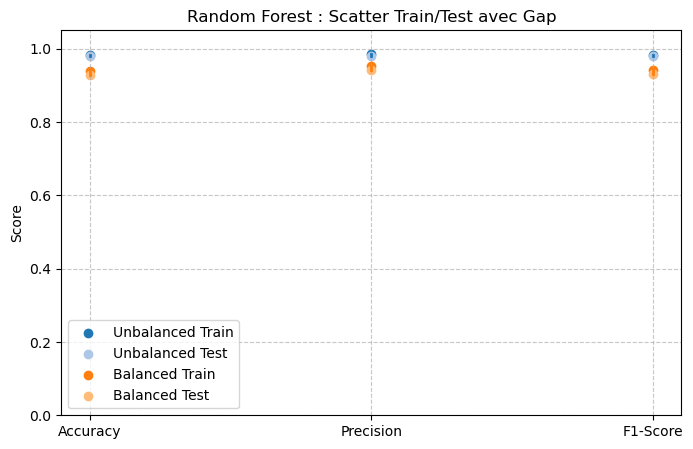

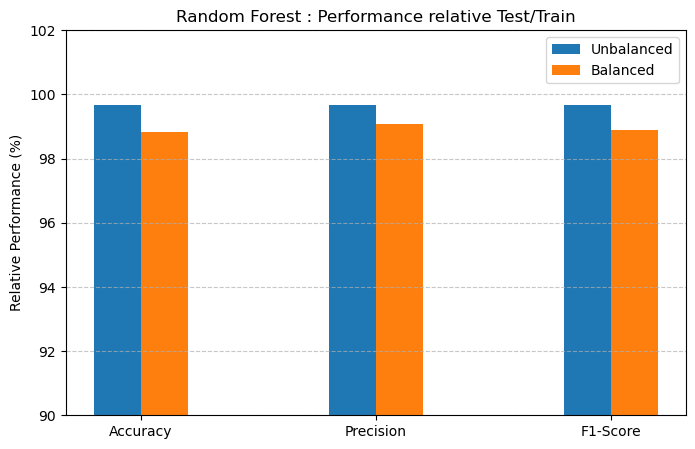

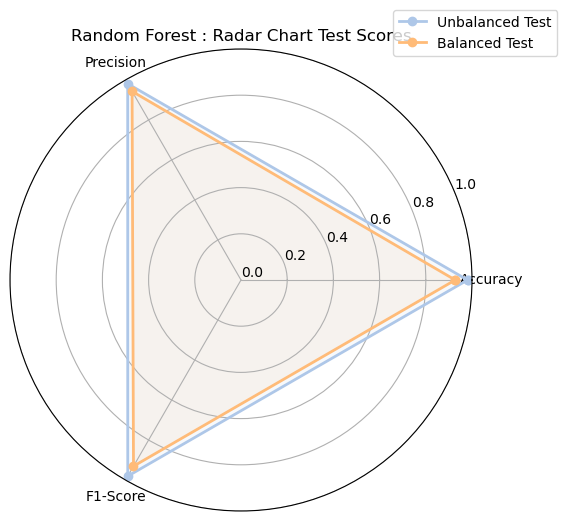

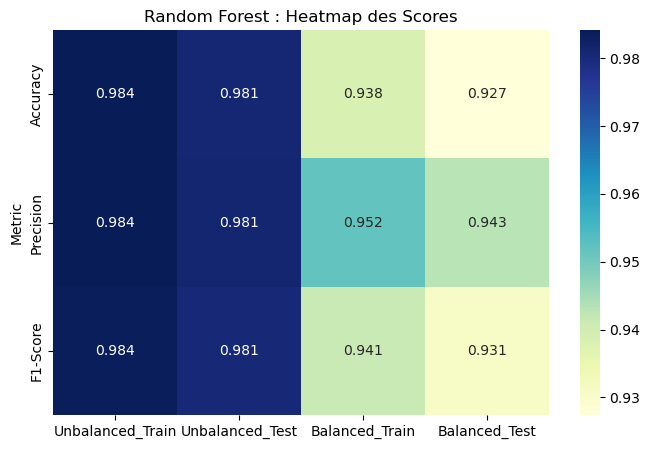

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

# ======================================
# 1️⃣ Données
# ======================================
data = {
    "Metric": ["Accuracy", "Precision", "F1-Score"],
    "Unbalanced_Train": [0.9839, 0.9841, 0.9836],
    "Unbalanced_Test": [0.9808, 0.9810, 0.9805],
    "Balanced_Train": [0.9384, 0.9518, 0.9412],
    "Balanced_Test": [0.9274, 0.9430, 0.9308]
}

df = pd.DataFrame(data)

# Calcul des gaps et performance relative
df['Unbalanced_Gap'] = df['Unbalanced_Train'] - df['Unbalanced_Test']
df['Balanced_Gap'] = df['Balanced_Train'] - df['Balanced_Test']
df['Unbalanced_Relative'] = df['Unbalanced_Test'] / df['Unbalanced_Train'] * 100
df['Balanced_Relative'] = df['Balanced_Test'] / df['Balanced_Train'] * 100

# ======================================
# 2️⃣ Barres Train/Test avec Gap
# ======================================
x = np.arange(len(df['Metric']))
width = 0.2

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x - width*1.5, df['Unbalanced_Train'], width, label='Unbalanced Train', color='#1f77b4')
ax.bar(x - width/2, df['Unbalanced_Test'], width, label='Unbalanced Test', color='#aec7e8')
ax.bar(x + width/2, df['Balanced_Train'], width, label='Balanced Train', color='#ff7f0e')
ax.bar(x + width*1.5, df['Balanced_Test'], width, label='Balanced Test', color='#ffbb78')
for i in range(len(df)):
    ax.text(x[i] - width/2, df['Unbalanced_Test'][i]+0.005, f"{df['Unbalanced_Gap'][i]:.3f}", ha='center', color='#1f77b4')
    ax.text(x[i] + width*1.5, df['Balanced_Test'][i]+0.005, f"{df['Balanced_Gap'][i]:.3f}", ha='center', color='#ff7f0e')
ax.set_xticks(x)
ax.set_xticklabels(df['Metric'])
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Random Forest : Train/Test avec Gap')
ax.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# ======================================
# 3️⃣ Lignes Train/Test
# ======================================
plt.figure(figsize=(8,5))
plt.plot(df['Metric'], df['Unbalanced_Train'], marker='o', label='Unbalanced Train', color='#1f77b4')
plt.plot(df['Metric'], df['Unbalanced_Test'], marker='o', label='Unbalanced Test', color='#aec7e8')
plt.plot(df['Metric'], df['Balanced_Train'], marker='o', label='Balanced Train', color='#ff7f0e')
plt.plot(df['Metric'], df['Balanced_Test'], marker='o', label='Balanced Test', color='#ffbb78')
plt.ylim(0,1.05)
plt.ylabel('Score')
plt.title('Random Forest : Lignes Train/Test')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# ======================================
# 4️⃣ Scatter plot avec ligne de gap
# ======================================
plt.figure(figsize=(8,5))
for i, metric in enumerate(df['Metric']):
    plt.plot([i, i], [df['Unbalanced_Train'][i], df['Unbalanced_Test'][i]], color='#1f77b4', linewidth=2)
    plt.scatter(i, df['Unbalanced_Train'][i], color='#1f77b4', label='Unbalanced Train' if i==0 else "")
    plt.scatter(i, df['Unbalanced_Test'][i], color='#aec7e8', label='Unbalanced Test' if i==0 else "")
    plt.plot([i, i], [df['Balanced_Train'][i], df['Balanced_Test'][i]], color='#ff7f0e', linewidth=2)
    plt.scatter(i, df['Balanced_Train'][i], color='#ff7f0e', label='Balanced Train' if i==0 else "")
    plt.scatter(i, df['Balanced_Test'][i], color='#ffbb78', label='Balanced Test' if i==0 else "")
plt.xticks(range(len(df['Metric'])), df['Metric'])
plt.ylim(0,1.05)
plt.ylabel('Score')
plt.title('Random Forest : Scatter Train/Test avec Gap')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# ======================================
# 5️⃣ Performance relative (%)
# ======================================
plt.figure(figsize=(8,5))
plt.bar(x - width/2, df['Unbalanced_Relative'], width, label='Unbalanced', color='#1f77b4')
plt.bar(x + width/2, df['Balanced_Relative'], width, label='Balanced', color='#ff7f0e')
plt.xticks(x, df['Metric'])
plt.ylabel('Relative Performance (%)')
plt.ylim(90, 102)
plt.title('Random Forest : Performance relative Test/Train')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# ======================================
# 6️⃣ Radar chart
# ======================================
from math import pi
categories = df['Metric']
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # fermer le cercle

fig = plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)

# Données
unbalanced_test = df['Unbalanced_Test'].tolist()
unbalanced_test += unbalanced_test[:1]
balanced_test = df['Balanced_Test'].tolist()
balanced_test += balanced_test[:1]

ax.plot(angles, unbalanced_test, 'o-', linewidth=2, label='Unbalanced Test', color='#aec7e8')
ax.fill(angles, unbalanced_test, alpha=0.1, color='#aec7e8')
ax.plot(angles, balanced_test, 'o-', linewidth=2, label='Balanced Test', color='#ffbb78')
ax.fill(angles, balanced_test, alpha=0.1, color='#ffbb78')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_yticks(np.arange(0.0, 1.1, 0.2))
ax.set_title('Random Forest : Radar Chart Test Scores')
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
plt.show()

# ======================================
# 7️⃣ Heatmap
# ======================================
heatmap_data = df.set_index('Metric')[['Unbalanced_Train','Unbalanced_Test','Balanced_Train','Balanced_Test']]
plt.figure(figsize=(8,5))
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap='YlGnBu', cbar=True)
plt.title('Random Forest : Heatmap des Scores')
plt.show()
